# Model Building v3 — Residual Modeling on top of `naive_seasonal_24h`

**Result from v2's walk-forward CV:** `naive_seasonal_24h` beat every ML model tried (linear regression, random forest, LightGBM, N-BEATS) on MAE, RMSE, and MAPE. That's a real, useful result — this data's daily seasonality is strong enough that "repeat last week's value at this hour" is a very hard baseline to beat from scratch.

So instead of asking a new model to learn demand from zero, this notebook makes `naive_seasonal_24h` **part of the model**:

$$\hat{y}_t = \text{naive}_t + \text{LightGBM}(\text{lags of actual demand, calendar features})$$

LightGBM is trained to predict the **residual** — `actual - naive` — not the raw demand. If it learns nothing useful, the residual prediction goes to ~0 and the result is just `naive_seasonal_24h` again. It can only help, not hurt (modulo overfitting noise, which walk-forward CV will show up).

Three models are compared, all under the same walk-forward CV:
1. `naive_seasonal_24h` — the current best, kept as the reference to beat
2. `lightgbm_raw` — LightGBM predicting raw demand directly (the v2 approach, kept for context)
3. `lightgbm_residual` — **new** — LightGBM predicting the residual on top of `naive_seasonal_24h`

In [1]:
!pip -q install darts lightgbm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 769.4 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.3/841.3 kB 5.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 20.3 MB/s eta 0:00:00


## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore",
                       message="The metric denominator is zero for some entries.*")
warnings.filterwarnings("ignore", category=UserWarning, module="darts")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from darts import TimeSeries
from darts.models import NaiveSeasonal, LightGBMModel
from darts.metrics import mae, rmse, mape, smape

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLORS = {
    "blue": "#2563EB",
    "purple": "#7C3AED",
    "green": "#059669",
    "amber": "#F59E0B",
    "red": "#DC2626",
    "slate": "#475569",
}

## Paths

In [3]:
PROJECT_DIR = Path("/kaggle/working/")
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FEATURE_DIR = PROJECT_DIR / "data" / "features"
MODEL_DIR = PROJECT_DIR / "models"
METRICS_DIR = PROJECT_DIR / "metrics"

for directory in (FEATURE_DIR, MODEL_DIR, METRICS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

HOURLY_ZONE_PATH = "/kaggle/input/datasets/sdeogade/nyc-taxi-processed/yellow_taxi_hourly_zone_demand_2026 (1).parquet"
print("Zone-level file:", HOURLY_ZONE_PATH)
# print("Exists:", HOURLY_ZONE_PATH.exists())1

Zone-level file: /kaggle/input/datasets/sdeogade/nyc-taxi-processed/yellow_taxi_hourly_zone_demand_2026 (1).parquet


## Load data, select zones, build the hourly panel
Same logic as the previous notebook: zero-fill genuine no-trip hours, interpolate true system-wide gaps, keep the zones covering 95% of total demand.

In [4]:
hourly_zone_demand = pd.read_parquet(HOURLY_ZONE_PATH)
hourly_zone_demand["timestamp"] = pd.to_datetime(hourly_zone_demand["timestamp"])
hourly_zone_demand["PULocationID"] = hourly_zone_demand["PULocationID"].astype(int)

zone_totals = (
    hourly_zone_demand.groupby("PULocationID")["demand"]
    .sum()
    .sort_values(ascending=False)
)
zone_share = zone_totals / zone_totals.sum()
zone_cumshare = zone_share.cumsum()

COVERAGE_TARGET = 0.99
SELECTED_ZONES = zone_cumshare[zone_cumshare <= COVERAGE_TARGET].index.tolist()

if len(SELECTED_ZONES) < len(zone_cumshare):
    SELECTED_ZONES.append(zone_cumshare.index[len(SELECTED_ZONES)])

panel = (
    hourly_zone_demand[
        hourly_zone_demand["PULocationID"].isin(SELECTED_ZONES)
    ]
    .pivot(index="timestamp", columns="PULocationID", values="demand")
    .sort_index()
)

expected_hours = pd.date_range(
    start=hourly_zone_demand["timestamp"].min(),
    end=hourly_zone_demand["timestamp"].max(),
    freq="h",
)
observed_hours = pd.DatetimeIndex(hourly_zone_demand["timestamp"].unique())
system_missing_hours = expected_hours.difference(observed_hours)

panel = panel.reindex(expected_hours)
panel.index.name = "timestamp"

# A zone with no trips during an observed system hour is a genuine zero.
observed_system_hours = panel.index.difference(system_missing_hours)
panel.loc[observed_system_hours] = panel.loc[observed_system_hours].fillna(0.0)

# Only true system-wide gaps are interpolated.
if len(system_missing_hours) > 0:
    panel = panel.interpolate(method="linear", limit_direction="both")

print(
    f"Zones selected: {len(SELECTED_ZONES)} / {len(zone_totals)} "
    f"({zone_share.loc[SELECTED_ZONES].sum() * 100:.1f}% of total demand)"
)
print("System-wide missing hours:", len(system_missing_hours))
print("Panel shape:", panel.shape)

Zones selected: 149 / 262 (99.0% of total demand)
System-wide missing hours: 1
Panel shape: (5088, 149)


## Build the naive-24h residual panel
`residual_t = actual_t - actual_{t-24}` — i.e. the error `naive_seasonal_24h` would make at every point in history. This is the *target* the residual model learns. The first 24 hours have no `t-24` value and are dropped.

In [5]:
SEASONAL_K = 24

# The 24-hour seasonal naive forecast at time t is y[t-24].
naive_24_panel = panel.shift(SEASONAL_K)
residual_panel = (panel - naive_24_panel).iloc[SEASONAL_K:]

print("Residual panel shape:", residual_panel.shape)
print(
    "Residual mean:",
    round(float(residual_panel.to_numpy().mean()), 3),
)
print(
    "Residual std:",
    round(float(residual_panel.to_numpy().std()), 3),
)

residual_panel.head()

Residual panel shape: (5064, 149)
Residual mean: 0.01
Residual std: 29.922


PULocationID,4,7,10,12,13,14,17,24,25,26,...,254,255,256,258,260,261,262,263,264,265
timestamp,,,,,,,,,,,,,,,,,,,,,
2026-01-02 00:00:00,-67.0,-26.0,-3.0,-1.0,-26.0,-5.0,-13.0,-22.0,-36.0,0.0,...,-5.0,-35.0,-29.0,-6.0,-6.0,-42.0,-108.0,-259.0,-9.0,-6.0
2026-01-02 01:00:00,-78.0,-63.0,-8.0,-1.0,-24.0,-10.0,-19.0,-41.0,-29.0,-1.0,...,-5.0,-51.0,-42.0,-8.0,-13.0,-28.0,-89.0,-291.0,-13.0,-1.0
2026-01-02 02:00:00,-72.0,-71.0,-2.0,-2.0,-16.0,-11.0,-21.0,-18.0,-29.0,-1.0,...,-1.0,-70.0,-70.0,-4.0,-15.0,-23.0,-31.0,-204.0,-7.0,-12.0
2026-01-02 03:00:00,-79.0,-65.0,0.0,-1.0,0.0,-13.0,-23.0,-12.0,-22.0,-1.0,...,-4.0,-74.0,-56.0,-5.0,-12.0,-10.0,-27.0,-127.0,-4.0,-5.0
2026-01-02 04:00:00,-66.0,-52.0,-3.0,0.0,-9.0,-8.0,-11.0,-13.0,-20.0,1.0,...,-1.0,-45.0,-51.0,0.0,-20.0,-12.0,-1.0,-89.0,-2.0,-11.0


## Convert to Darts TimeSeries

In [6]:
zone_ids = [str(c) for c in panel.columns]

raw_multiseries = TimeSeries.from_times_and_values(
    times=panel.index,
    values=panel.values,
    columns=zone_ids,
    freq="h",
)
raw_series_list = [
    raw_multiseries.univariate_component(i)
    for i in range(raw_multiseries.n_components)
]

residual_multiseries = TimeSeries.from_times_and_values(
    times=residual_panel.index,
    values=residual_panel.values,
    columns=zone_ids,
    freq="h",
)
residual_series_list = [
    residual_multiseries.univariate_component(i)
    for i in range(residual_multiseries.n_components)
]

calendar_df = pd.DataFrame(index=panel.index)
calendar_df["hour"] = calendar_df.index.hour
calendar_df["day_of_week"] = calendar_df.index.dayofweek
calendar_df["is_weekend"] = calendar_df["day_of_week"].isin([5, 6]).astype(int)
calendar_df["day_of_month"] = calendar_df.index.day
calendar_df["month"] = calendar_df.index.month

calendar_covariates = TimeSeries.from_times_and_values(
    times=calendar_df.index,
    values=calendar_df.values,
    columns=calendar_df.columns.tolist(),
    freq="h",
)

covariates_list = [calendar_covariates] * len(raw_series_list)

print(
    f"{len(raw_series_list)} zones | "
    f"raw length {len(raw_series_list[0])} | "
    f"residual length {len(residual_series_list[0])}"
)

149 zones | raw length 5088 | residual length 5064


## Final holdout (unchanged from v2 — last 14 days, untouched by CV)

In [7]:
FINAL_HOLDOUT_HOURS = 14 * 24

cv_raw_series = [s[:-FINAL_HOLDOUT_HOURS] for s in raw_series_list]
holdout_raw_series = [s[-FINAL_HOLDOUT_HOURS:] for s in raw_series_list]

# Residual series starts 24 hours after the raw series.
cv_residual_series = [
    r[: len(r) - FINAL_HOLDOUT_HOURS]
    for r in residual_series_list
]
cv_covariates = [c[:-FINAL_HOLDOUT_HOURS] for c in covariates_list]

print("CV raw pool length:     ", len(cv_raw_series[0]))
print("CV residual pool length:", len(cv_residual_series[0]))
print("Final holdout length:   ", len(holdout_raw_series[0]))

CV raw pool length:      4752
CV residual pool length: 4728
Final holdout length:    336


## Walk-forward folds (same scheme as v2)

In [8]:
WF_HORIZON = 48
WF_STRIDE = 7 * 24
WF_MIN_TRAIN = 60 * 24


def make_walk_forward_folds(total_length, min_train_size, horizon, stride):
    folds = []
    train_end = min_train_size

    while train_end + horizon <= total_length:
        folds.append((train_end, train_end + horizon))
        train_end += stride

    return folds


WF_FOLDS = make_walk_forward_folds(
    len(cv_raw_series[0]),
    WF_MIN_TRAIN,
    WF_HORIZON,
    WF_STRIDE,
)

print(f"Generated {len(WF_FOLDS)} walk-forward folds")

Generated 20 walk-forward folds


## Lags (carried over from v2 — tied to the EDA's ACF findings)
Same-hour value from each of the last 7 days (the ACF's peak structure), plus a few very recent lags for short-term momentum. `lags_past_covariates` here plays the role `lags` played in v2, since the raw demand is now a *covariate* to the residual model rather than its own target.

In [9]:
LAGS = [-1, -2, -3, -24, -48, -72, -96, -120, -144, -168]

## Model registry — three models, one comparison
- `naive_seasonal_24h`: local, fit independently per zone, no features
- `lightgbm_raw`: global, predicts raw demand directly from `LAGS` + calendar covariates (v2's approach)
- `lightgbm_residual`: global, predicts the **residual** on top of `naive_seasonal_24h`, using the same `LAGS` as **past covariates** (not target lags, since the target here is the residual, not the raw demand) plus the same calendar future covariates

In [10]:
MODEL_REGISTRY = {
    "naive_seasonal_24h": {
        "kind": "naive",
        "tier": "Baseline",
    },
    "lightgbm_raw": {
        "kind": "global_raw",
        "tier": "LightGBM on raw demand",
        "builder": lambda horizon: LightGBMModel(
            lags=LAGS,
            lags_future_covariates=[0],
            output_chunk_length=horizon,
            random_state=42,
            device="gpu",
            verbose=-1,
        ),
    },
    "lightgbm_residual": {
        "kind": "residual",
        "tier": "LightGBM on naive residuals",
        "builder": lambda horizon: LightGBMModel(
            lags=None,
            lags_past_covariates=LAGS,
            lags_future_covariates=[0],
            output_chunk_length=horizon,
            random_state=42,
            device="gpu",
            verbose=-1,
        ),
    },
}

for name, cfg in MODEL_REGISTRY.items():
    print(f"{name:>22s} | {cfg['tier']}")

    naive_seasonal_24h | Baseline
          lightgbm_raw | LightGBM on raw demand
     lightgbm_residual | LightGBM on naive residuals


## Walk-forward CV runner
Each `kind` needs slightly different fit/predict plumbing:
- **naive**: fit + predict independently per zone, no features
- **global_raw**: one global fit on raw demand series, using `LAGS` as target lags + calendar future covariates
- **residual**: one global fit on the residual series, using raw demand as `past_covariates` (source of `LAGS`) + calendar future covariates, then `naive_seasonal_24h + predicted_residual` is the final forecast, **clipped at 0** since demand can't be negative

In [11]:
def compute_metrics(actual: TimeSeries, predicted: TimeSeries) -> dict:
    # MAPE is undefined when actual == 0.
    # Remove zero-actual timestamps before calculating MAPE.
    actual_values = actual.values(copy=False).squeeze()
    predicted_values = predicted.values(copy=False).squeeze()

    nonzero_mask = actual_values != 0

    if nonzero_mask.any():
        mape_value = np.mean(
            np.abs(
                (actual_values[nonzero_mask] - predicted_values[nonzero_mask])
                / actual_values[nonzero_mask]
            )
        ) * 100
    else:
        mape_value = np.nan

    return {
        "mae": mae(actual, predicted),
        "rmse": rmse(actual, predicted),
        "mape": mape_value,
        "smape": smape(actual, predicted),
    }


def clip_nonnegative(series_list):
    return [
        s.map(lambda x: np.maximum(x, 0.0))
        for s in series_list
    ]


def run_fold(model_name, model_cfg, train_end, test_end):
    horizon = test_end - train_end

    fold_raw_train = [s[:train_end] for s in cv_raw_series]
    fold_raw_test = [s[train_end:test_end] for s in cv_raw_series]
    fold_future_cov_train = [c[:train_end] for c in cv_covariates]
    fold_future_cov_full = [c[:test_end] for c in cv_covariates]

    rows = []

    if model_cfg["kind"] == "naive":
        for zone_id, train_s, test_s in zip(
            zone_ids, fold_raw_train, fold_raw_test
        ):
            model = NaiveSeasonal(K=SEASONAL_K)
            model.fit(train_s)
            pred = model.predict(horizon)
            rows.append({"zone": zone_id, **compute_metrics(test_s, pred)})
        return rows

    if model_cfg["kind"] == "global_raw":
        model = model_cfg["builder"](horizon)
        model.fit(
            series=fold_raw_train,
            future_covariates=fold_future_cov_train,
        )
        predictions = model.predict(
            n=horizon,
            series=fold_raw_train,
            future_covariates=fold_future_cov_full,
        )
        predictions = clip_nonnegative(predictions)

        for zone_id, test_s, pred in zip(
            zone_ids, fold_raw_test, predictions
        ):
            rows.append({"zone": zone_id, **compute_metrics(test_s, pred)})
        return rows

    if model_cfg["kind"] == "residual":
        # Residual target is shifted by SEASONAL_K hours relative to raw demand.
        fold_residual_train = [
            r[: train_end - SEASONAL_K]
            for r in cv_residual_series
        ]

        model = model_cfg["builder"](horizon)
        model.fit(
            series=fold_residual_train,
            past_covariates=fold_raw_train,
            future_covariates=fold_future_cov_train,
        )

        residual_predictions = model.predict(
            n=horizon,
            series=fold_residual_train,
            past_covariates=fold_raw_train,
            future_covariates=fold_future_cov_full,
        )

        naive_predictions = []
        for train_s in fold_raw_train:
            naive_model = NaiveSeasonal(K=SEASONAL_K)
            naive_model.fit(train_s)
            naive_predictions.append(naive_model.predict(horizon))

        final_predictions = clip_nonnegative([
            naive_pred + residual_pred
            for naive_pred, residual_pred in zip(
                naive_predictions, residual_predictions
            )
        ])

        for zone_id, test_s, pred in zip(
            zone_ids, fold_raw_test, final_predictions
        ):
            rows.append({"zone": zone_id, **compute_metrics(test_s, pred)})
        return rows

    raise ValueError(f"Unknown model kind: {model_cfg['kind']}")


def run_walk_forward_cv(model_name, model_cfg, folds=WF_FOLDS):
    all_rows = []

    for fold_idx, (train_end, test_end) in enumerate(folds, start=1):
        fold_rows = run_fold(model_name, model_cfg, train_end, test_end)

        for row in fold_rows:
            row["fold"] = fold_idx
            row["model"] = model_name

        all_rows.extend(fold_rows)

    return pd.DataFrame(all_rows)

## Run walk-forward CV for all three models
`lightgbm_residual` fits two models per fold (the residual LightGBM + a `NaiveSeasonal` per zone), so it's a bit slower than `lightgbm_raw` per fold, but still one global fit per fold rather than one per zone.

In [12]:
cv_results = []

for model_name, model_cfg in MODEL_REGISTRY.items():
    print(f"Running walk-forward CV for: {model_name} ({model_cfg['tier']})")
    result_df = run_walk_forward_cv(model_name, model_cfg)
    cv_results.append(result_df)

cv_results = pd.concat(cv_results, ignore_index=True)
display(cv_results.head())

Running walk-forward CV for: naive_seasonal_24h (Baseline)


The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is 

Running walk-forward CV for: lightgbm_raw (LightGBM on raw demand)


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature n

Running walk-forward CV for: lightgbm_residual (LightGBM on naive residuals)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

,zone,mae,rmse,mape,smape,fold,model
0,4,24.583333,44.031239,536.443514,80.831275,1,naive_seasonal_24h
1,7,10.645833,14.054211,248.063139,80.918774,1,naive_seasonal_24h
2,10,2.541667,3.541422,85.869544,91.006541,1,naive_seasonal_24h
3,12,0.875000,1.670828,76.666667,75.505051,1,naive_seasonal_24h
4,13,24.312500,33.414381,121.332912,114.416488,1,naive_seasonal_24h


## Cross-validated comparison

In [13]:
cv_summary = (
    cv_results
    .groupby("model")[['mae', 'rmse', 'mape', 'smape']]
    .agg(['mean', 'std'])
)

cv_summary.insert(
    0,
    "tier",
    [MODEL_REGISTRY[m]["tier"] for m in cv_summary.index],
)

cv_summary = cv_summary.sort_values(("mae", "mean"))
display(cv_summary)

tier        mae             \
                                                      mean        std   
model                                                                   
lightgbm_raw             LightGBM on raw demand  14.313022  20.821220   
lightgbm_residual   LightGBM on naive residuals  15.700645  21.080708   
naive_seasonal_24h                     Baseline  18.587563  27.828244   

                         rmse                   mape                  smape  \
                         mean        std        mean         std       mean   
model                                                                         
lightgbm_raw        18.786759  27.523208  139.923026  185.392224  86.427560   
lightgbm_residual   22.533412  32.156241  169.236184  164.636131  89.032306   
naive_seasonal_24h  26.596287  41.587440  172.493921  170.794913  84.765701   

                               
                          std  
model                          
lightgbm_raw        36.893377  
lightgbm_residual   31.243359  
naive_seasonal_24h  23.116544

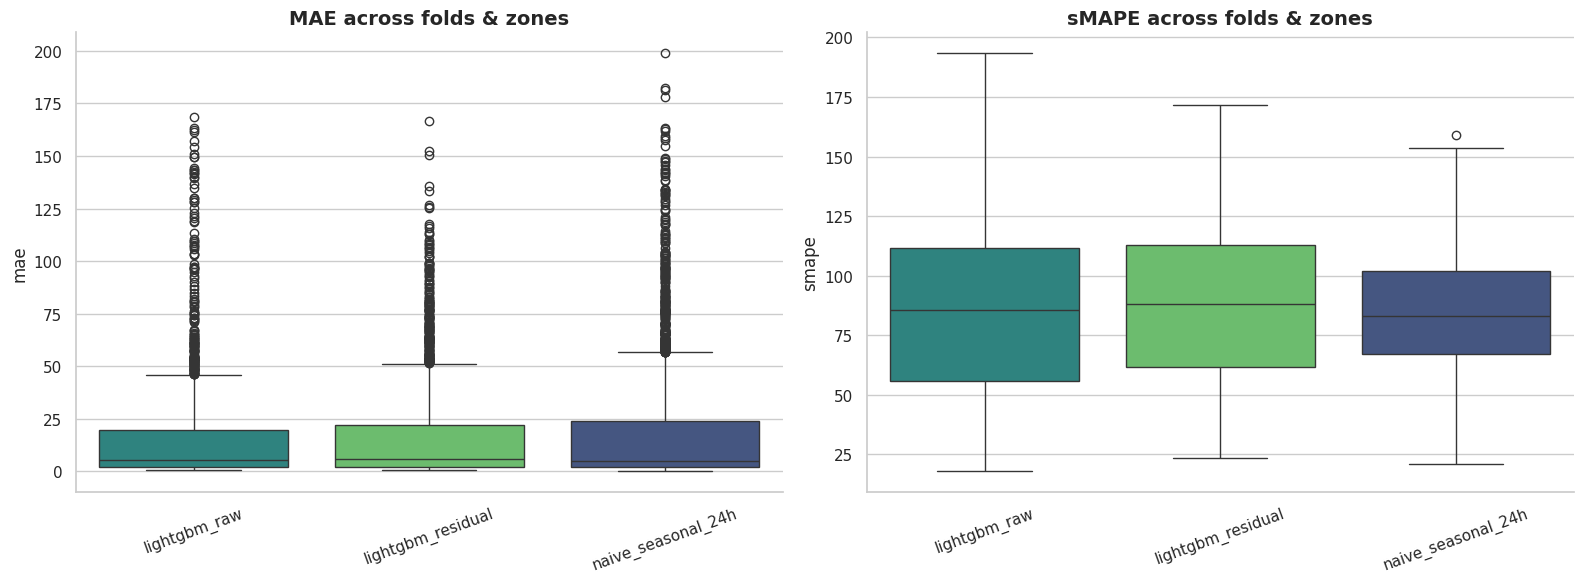

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
order = cv_summary.index.tolist()

sns.boxplot(
    data=cv_results,
    x="model",
    y="mae",
    order=order,
    ax=axes[0],
    hue="model",
    palette="viridis",
    legend=False,
)
axes[0].set_title("MAE across folds & zones", fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(
    data=cv_results,
    x="model",
    y="smape",
    order=order,
    ax=axes[1],
    hue="model",
    palette="viridis",
    legend=False,
)
axes[1].set_title("sMAPE across folds & zones", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

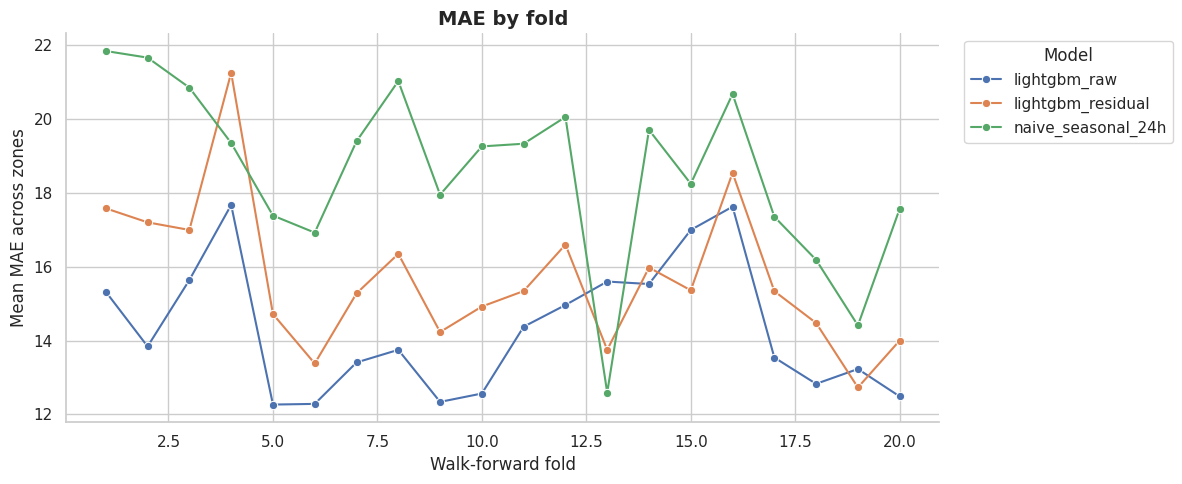

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))

fold_trend = (
    cv_results.groupby(["fold", "model"])["mae"]
    .mean()
    .reset_index()
)

sns.lineplot(
    data=fold_trend,
    x="fold",
    y="mae",
    hue="model",
    marker="o",
    ax=ax,
)
ax.set_title(
    "MAE by fold",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Walk-forward fold")
ax.set_ylabel("Mean MAE across zones")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [16]:
pivot = cv_results.pivot_table(
    index=["fold", "zone"],
    columns="model",
    values="mae",
)

win_rate = (
    pivot["lightgbm_residual"] < pivot["naive_seasonal_24h"]
).mean()

mean_improvement = (
    pivot["naive_seasonal_24h"] - pivot["lightgbm_residual"]
).mean()

print(
    f"lightgbm_residual beats naive_seasonal_24h on "
    f"{win_rate * 100:.1f}% of (fold, zone) combinations"
)
print(f"Mean MAE improvement: {mean_improvement:.3f} trips/hour")

lightgbm_residual beats naive_seasonal_24h on 41.9% of (fold, zone) combinations
Mean MAE improvement: 2.887 trips/hour


## Final holdout evaluation (all 3 models, same untouched 14-day block)

In [17]:
def fit_and_predict_holdout(model_name, model_cfg):
    horizon = FINAL_HOLDOUT_HOURS

    if model_cfg["kind"] == "naive":
        rows = []
        for zone_id, train_s, test_s in zip(
            zone_ids, cv_raw_series, holdout_raw_series
        ):
            model = NaiveSeasonal(K=SEASONAL_K)
            model.fit(train_s)
            pred = model.predict(horizon)
            rows.append({
                "zone": zone_id,
                "model": model_name,
                **compute_metrics(test_s, pred),
            })
        return rows, None

    if model_cfg["kind"] == "global_raw":
        model = model_cfg["builder"](horizon)
        model.fit(
            series=cv_raw_series,
            future_covariates=cv_covariates,
        )
        predictions = model.predict(
            n=horizon,
            series=cv_raw_series,
            future_covariates=covariates_list,
        )
        predictions = clip_nonnegative(predictions)

        rows = [
            {
                "zone": zone_id,
                "model": model_name,
                **compute_metrics(test_s, pred),
            }
            for zone_id, test_s, pred in zip(
                zone_ids, holdout_raw_series, predictions
            )
        ]
        return rows, model

    if model_cfg["kind"] == "residual":
        model = model_cfg["builder"](horizon)
        model.fit(
            series=cv_residual_series,
            past_covariates=cv_raw_series,
            future_covariates=cv_covariates,
        )
        residual_predictions = model.predict(
            n=horizon,
            series=cv_residual_series,
            past_covariates=cv_raw_series,
            future_covariates=covariates_list,
        )

        naive_predictions = []
        for train_s in cv_raw_series:
            naive_model = NaiveSeasonal(K=SEASONAL_K)
            naive_model.fit(train_s)
            naive_predictions.append(naive_model.predict(horizon))

        final_predictions = clip_nonnegative([
            naive_pred + residual_pred
            for naive_pred, residual_pred in zip(
                naive_predictions, residual_predictions
            )
        ])

        rows = [
            {
                "zone": zone_id,
                "model": model_name,
                **compute_metrics(test_s, pred),
            }
            for zone_id, test_s, pred in zip(
                zone_ids, holdout_raw_series, final_predictions
            )
        ]
        return rows, model

    raise ValueError(f"Unknown model kind: {model_cfg['kind']}")


holdout_results = []
fitted_models = {}

for model_name, model_cfg in MODEL_REGISTRY.items():
    print(f"Evaluating on final holdout: {model_name}")
    rows, fitted_model = fit_and_predict_holdout(model_name, model_cfg)
    holdout_results.extend(rows)

    if fitted_model is not None:
        fitted_models[model_name] = fitted_model

holdout_results = pd.DataFrame(holdout_results)

holdout_summary = (
    holdout_results
    .groupby("model")[['mae', 'rmse', 'mape', 'smape']]
    .mean()
    .sort_values("mae")
)

holdout_summary.insert(
    0,
    "tier",
    [MODEL_REGISTRY[m]["tier"] for m in holdout_summary.index],
)

display(holdout_summary)

The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is 

Evaluating on final holdout: naive_seasonal_24h


The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is non-zero and 0.0 when the numerator is also zero.
The metric denominator is zero for some entries. Those entries are set to NaN when the numerator is 

Evaluating on final holdout: lightgbm_raw


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

Evaluating on final holdout: lightgbm_residual


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

,tier,mae,rmse,mape,smape
model,,,,,
naive_seasonal_24h,Baseline,11.367170,16.904504,78.780541,70.227937
lightgbm_raw,LightGBM on raw demand,11.378989,15.653094,78.824756,87.363230
lightgbm_residual,LightGBM on naive residuals,11.899535,17.153487,86.513847,87.975080


In [18]:
comparison_table = (
    cv_summary[[
        ("mae", "mean"),
        ("rmse", "mean"),
        ("mape", "mean"),
        ("smape", "mean"),
    ]]
    .droplevel(1, axis=1)
    .rename(columns=lambda c: f"cv_{c}")
    .join(
        holdout_summary[["mae", "rmse", "mape", "smape"]]
        .rename(columns=lambda c: f"holdout_{c}")
    )
)

comparison_table.insert(
    0,
    "tier",
    [MODEL_REGISTRY[m]["tier"] for m in comparison_table.index],
)

comparison_table = comparison_table.sort_values("holdout_mae")
display(comparison_table)

,tier,cv_mae,cv_rmse,cv_mape,cv_smape,holdout_mae,holdout_rmse,holdout_mape,holdout_smape
model,,,,,,,,,
naive_seasonal_24h,Baseline,18.587563,26.596287,172.493921,84.765701,11.367170,16.904504,78.780541,70.227937
lightgbm_raw,LightGBM on raw demand,14.313022,18.786759,139.923026,86.427560,11.378989,15.653094,78.824756,87.363230
lightgbm_residual,LightGBM on naive residuals,15.700645,22.533412,169.236184,89.032306,11.899535,17.153487,86.513847,87.975080


## Inference — forecast the next 7 days with the winning model
Picks the model with the lowest final-holdout MAE and refits it on **all** available history (`raw_series_list` / `residual_series_list`, no holdout carved out) before forecasting beyond the end of the dataset.

In [24]:
SELECTION_METRIC = "cv_mae"
best_model_name = comparison_table[SELECTION_METRIC].idxmin()
best_model_cfg = MODEL_REGISTRY[best_model_name]

print(
    f"Selected model by {SELECTION_METRIC}: "
    f"{best_model_name} ({best_model_cfg['tier']})"
)

INFERENCE_HORIZON = 7 * 24

future_index = pd.date_range(
    start=panel.index[0],
    periods=len(panel.index) + INFERENCE_HORIZON,
    freq="h",
)

future_calendar_df = pd.DataFrame(index=future_index)
future_calendar_df["hour"] = future_calendar_df.index.hour
future_calendar_df["day_of_week"] = future_calendar_df.index.dayofweek
future_calendar_df["is_weekend"] = future_calendar_df["day_of_week"].isin([5, 6]).astype(int)
future_calendar_df["day_of_month"] = future_calendar_df.index.day
future_calendar_df["month"] = future_calendar_df.index.month

future_covariates = TimeSeries.from_times_and_values(
    times=future_calendar_df.index,
    values=future_calendar_df.values,
    columns=future_calendar_df.columns.tolist(),
    freq="h",
)
full_covariates_list = [future_covariates] * len(raw_series_list)

if best_model_cfg["kind"] == "naive":
    future_predictions = []
    for series in raw_series_list:
        model = NaiveSeasonal(K=SEASONAL_K)
        model.fit(series)
        future_predictions.append(model.predict(INFERENCE_HORIZON))

elif best_model_cfg["kind"] == "global_raw":
    production_model = best_model_cfg["builder"](INFERENCE_HORIZON)
    production_model.fit(
        series=raw_series_list,
        future_covariates=full_covariates_list,
    )
    future_predictions = production_model.predict(
        n=INFERENCE_HORIZON,
        series=raw_series_list,
        future_covariates=full_covariates_list,
    )
    future_predictions = clip_nonnegative(future_predictions)

elif best_model_cfg["kind"] == "residual":
    production_model = best_model_cfg["builder"](INFERENCE_HORIZON)
    production_model.fit(
        series=residual_series_list,
        past_covariates=raw_series_list,
        future_covariates=full_covariates_list,
    )
    residual_predictions = production_model.predict(
        n=INFERENCE_HORIZON,
        series=residual_series_list,
        past_covariates=raw_series_list,
        future_covariates=full_covariates_list,
    )

    naive_predictions = []
    for series in raw_series_list:
        model = NaiveSeasonal(K=SEASONAL_K)
        model.fit(series)
        naive_predictions.append(model.predict(INFERENCE_HORIZON))

    future_predictions = clip_nonnegative([
        naive_pred + residual_pred
        for naive_pred, residual_pred in zip(
            naive_predictions, residual_predictions
        )
    ])

print(
    f"Forecasted {INFERENCE_HORIZON}h ahead for "
    f"{len(future_predictions)} zones using {best_model_name}"
)
print(
    "Forecast window:",
    future_predictions[0].start_time(),
    "→",
    future_predictions[0].end_time(),
)

Selected model by cv_mae: lightgbm_raw (LightGBM on raw demand)
Forecasted 168h ahead for 149 zones using lightgbm_raw
Forecast window: 2026-08-01 00:00:00 → 2026-08-07 23:00:00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

In [29]:
inference_rows = []

for zone_id, pred in zip(zone_ids, future_predictions):
    df = pd.DataFrame(
        {
            "timestamp": pred.time_index,
            "forecast_demand": pred.values(copy=False).squeeze(),
        }
    )

    df["PULocationID"] = zone_id
    inference_rows.append(df)

inference_df = pd.concat(inference_rows, ignore_index=True)

# Demand cannot be negative
inference_df["forecast_demand"] = inference_df["forecast_demand"].clip(lower=0)

print("Inference shape:", inference_df.shape)
display(inference_df.head())

Inference shape: (25032, 3)


,timestamp,forecast_demand,PULocationID
0,2026-08-01 00:00:00,72.030377,4
1,2026-08-01 01:00:00,52.815767,4
2,2026-08-01 02:00:00,33.847609,4
3,2026-08-01 03:00:00,16.542777,4
4,2026-08-01 04:00:00,10.940128,4


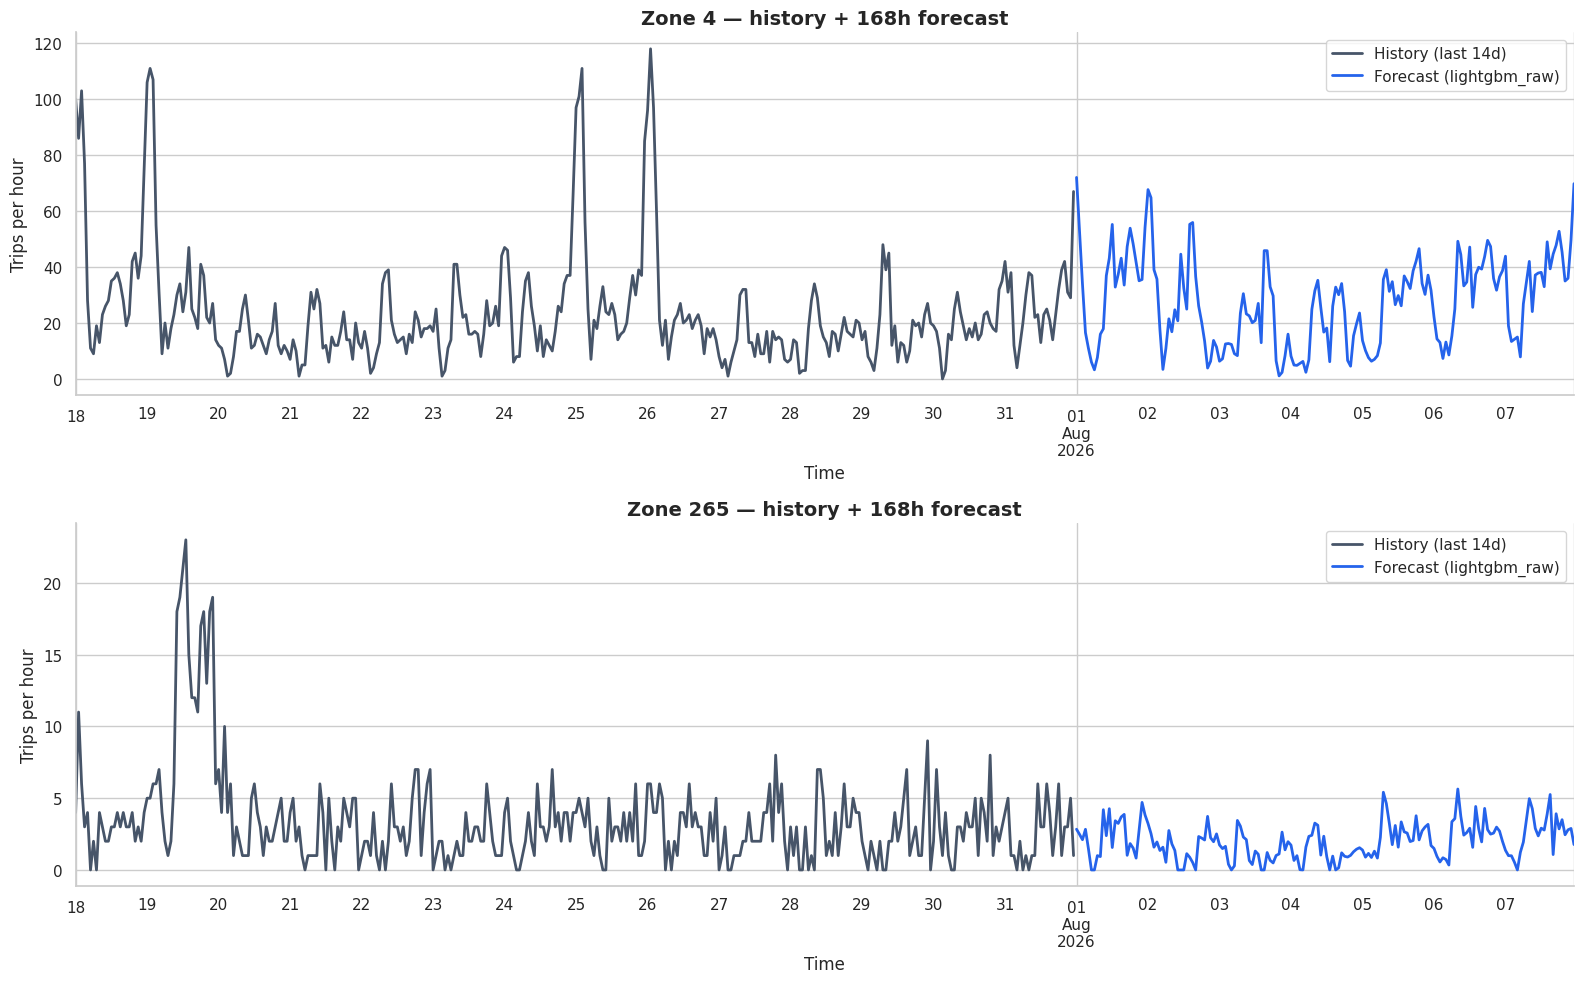

In [27]:
sample_zone_ids = [zone_ids[0], zone_ids[-1]]

fig, axes = plt.subplots(
    len(sample_zone_ids),
    1,
    figsize=(16, 5 * len(sample_zone_ids)),
)

for ax, zone_id in zip(np.atleast_1d(axes), sample_zone_ids):
    idx = zone_ids.index(zone_id)

    raw_series_list[idx][-14 * 24:].plot(
        ax=ax,
        label="History (last 14d)",
        color=COLORS["slate"],
    )
    future_predictions[idx].plot(
        ax=ax,
        label=f"Forecast ({best_model_name})",
        color=COLORS["blue"],
    )

    ax.set_title(
        f"Zone {zone_id} — history + {INFERENCE_HORIZON}h forecast",
        fontsize=14,
        fontweight="bold",
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Trips per hour")
    ax.legend()

plt.tight_layout()
plt.show()

## Save everything

In [28]:
CV_METRICS_PATH = "v2_walk_forward_cv_results.csv"
HOLDOUT_METRICS_PATH = "v2_final_holdout_results.csv"
COMPARISON_PATH = "v2_model_comparison_summary.csv"
INFERENCE_PATH = "v2_inference_forecast_next_7d.parquet"

cv_results.to_csv(CV_METRICS_PATH, index=False)
holdout_results.to_csv(HOLDOUT_METRICS_PATH, index=False)
comparison_table.to_csv(COMPARISON_PATH)
inference_df.to_parquet(INFERENCE_PATH, index=False)

if best_model_name in fitted_models:
    MODEL_PATH = MODEL_DIR / f"{best_model_name}_v2.pt"
    fitted_models[best_model_name].save(str(MODEL_PATH))
    print("Saved model to:", MODEL_PATH)

print("Saved CV metrics to:      ", CV_METRICS_PATH)
print("Saved holdout metrics to: ", HOLDOUT_METRICS_PATH)
print("Saved comparison table to:", COMPARISON_PATH)
print("Saved inference output to:", INFERENCE_PATH)
print(f"Selected model: {best_model_name}")
display(comparison_table)

Saved model to: /kaggle/working/models/lightgbm_raw_v2.pt
Saved CV metrics to:       v2_walk_forward_cv_results.csv
Saved holdout metrics to:  v2_final_holdout_results.csv
Saved comparison table to: v2_model_comparison_summary.csv
Saved inference output to: v2_inference_forecast_next_7d.parquet
Selected model: lightgbm_raw


,tier,cv_mae,cv_rmse,cv_mape,cv_smape,holdout_mae,holdout_rmse,holdout_mape,holdout_smape
model,,,,,,,,,
naive_seasonal_24h,Baseline,18.587563,26.596287,172.493921,84.765701,11.367170,16.904504,78.780541,70.227937
lightgbm_raw,LightGBM on raw demand,14.313022,18.786759,139.923026,86.427560,11.378989,15.653094,78.824756,87.363230
lightgbm_residual,LightGBM on naive residuals,15.700645,22.533412,169.236184,89.032306,11.899535,17.153487,86.513847,87.975080


## Reading the result

Use the CV and final-holdout metrics to document how each model performed. The notebook does not assume that the residual model improves on the baseline; the saved tables contain the evidence needed for that conclusion.
